In [20]:
import pandas as pd
df=pd.read_csv(r"C:\Users\Admin\OneDrive\Desktop\Projects\WA_Fn-UseC_-Telco-Customer-Churn.csv")
df.shape


(7043, 21)

In [21]:
df.head()


,customerID,gender,SeniorCitizen,Partner,Dependents,tenure,PhoneService,MultipleLines,InternetService,OnlineSecurity,...,DeviceProtection,TechSupport,StreamingTV,StreamingMovies,Contract,PaperlessBilling,PaymentMethod,MonthlyCharges,TotalCharges,Churn
0,7590-VHVEG,Female,0,Yes,No,1,No,No phone service,DSL,No,...,No,No,No,No,Month-to-month,Yes,Electronic check,29.85,29.85,No
1,5575-GNVDE,Male,0,No,No,34,Yes,No,DSL,Yes,...,Yes,No,No,No,One year,No,Mailed check,56.95,1889.5,No
2,3668-QPYBK,Male,0,No,No,2,Yes,No,DSL,Yes,...,No,No,No,No,Month-to-month,Yes,Mailed check,53.85,108.15,Yes
3,7795-CFOCW,Male,0,No,No,45,No,No phone service,DSL,Yes,...,Yes,Yes,No,No,One year,No,Bank transfer (automatic),42.30,1840.75,No
4,9237-HQITU,Female,0,No,No,2,Yes,No,Fiber optic,No,...,No,No,No,No,Month-to-month,Yes,Electronic check,70.70,151.65,Yes


In [22]:
df.dtypes


customerID              str
gender                  str
SeniorCitizen         int64
Partner                 str
Dependents              str
tenure                int64
PhoneService            str
MultipleLines           str
InternetService         str
OnlineSecurity          str
OnlineBackup            str
DeviceProtection        str
TechSupport             str
StreamingTV             str
StreamingMovies         str
Contract                str
PaperlessBilling        str
PaymentMethod           str
MonthlyCharges      float64
TotalCharges            str
Churn                   str
dtype: object

In [23]:
df.isnull().sum()

customerID          0
gender              0
SeniorCitizen       0
Partner             0
Dependents          0
tenure              0
PhoneService        0
MultipleLines       0
InternetService     0
OnlineSecurity      0
OnlineBackup        0
DeviceProtection    0
TechSupport         0
StreamingTV         0
StreamingMovies     0
Contract            0
PaperlessBilling    0
PaymentMethod       0
MonthlyCharges      0
TotalCharges        0
Churn               0
dtype: int64

PHASE 3 - DATA CLEANING

In [ ]:
# Fix TotalCharges — stored as string, has spaces
df['TotalCharges'] = pd.to_numeric(df['TotalCharges'], errors='coerce')

# Check how many nulls got created
df['TotalCharges'].isnull().sum()  # will show 11

# Drop those 11 rows — too few to impute
df.dropna(inplace=True)

# Convert Churn to binary
df['Churn'] = df['Churn'].map({'Yes': 1, 'No': 0})


In [25]:
# Verify final shape
df.shape  # should be (7032, 20)

(7032, 21)

In [ ]:
df.to_csv("Churn_clean.csv", index=False)

PHASE 4-EDA

Text(0.5, 1.0, 'Overall Churn Rate')

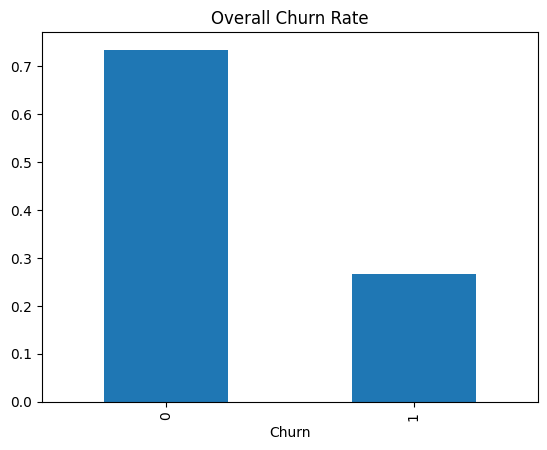

In [29]:
#Overall Churn Rate

import matplotlib.pyplot as plt
df['Churn'].value_counts(normalize=True).plot(kind='bar')
plt.title("Overall Churn Rate")

Text(0.5, 1.0, 'Churn by Contract Type')

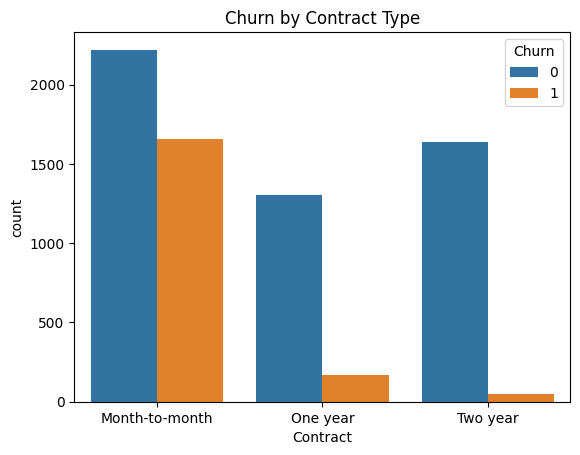

In [30]:
#Churn by Contract Type

import seaborn as sns
sns.countplot(x='Contract',hue='Churn',data=df)
plt.title("Churn by Contract Type")

<Axes: xlabel='tenure', ylabel='Count'>

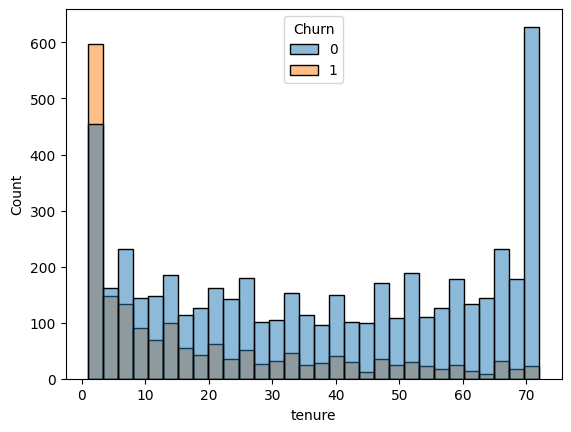

In [31]:
#Churn by Tenure

sns.histplot(data=df, x='tenure',hue='Churn',bins=30)

<Axes: xlabel='Churn', ylabel='MonthlyCharges'>

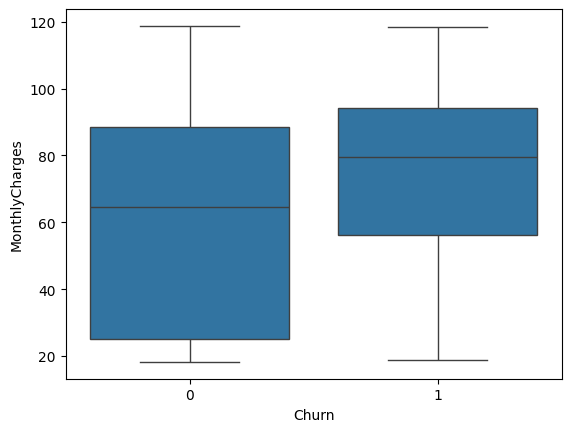

In [33]:
#Churn by Monthly Charges

sns.boxplot(x='Churn',y='MonthlyCharges',data=df)

PHASE - 5

In [ ]:
# Tenure buckets
df['TenureGroup'] = pd.cut(df['tenure'],
    bins=[0, 12, 24, 48, 72],
    labels=['0-12 months', '13-24 months', '25-48 months', '48+ months'])

# High value flag (top 20% by monthly charges)
threshold = df['MonthlyCharges'].quantile(0.80)
df['HighValue'] = (df['MonthlyCharges'] >= threshold).astype(int)

# Revenue at risk per customer
df['RevenueAtRisk'] = df['MonthlyCharges'] * df['Churn']

# Save enriched file
df.to_csv("churn_enriched.csv", index=False)

PHASE - 6

In [35]:
from scipy.stats import chi2_contingency

# Test: Is Contract Type significantly related to Churn?
ct = pd.crosstab(df['Contract'], df['Churn'])
chi2, p, dof, expected = chi2_contingency(ct)
print(f"p-value: {p}")
# If p < 0.05 → statistically significant

p-value: 7.326182186265472e-257


Contract type (p=0.00), tenure group (p=0.00), and internet service (p=0.00) are statistically significant churn drivers.